# Demeter SDK - Demo en Google Colab

**Servidor:** `https://patata.monters.org`  
**API docs:** `https://patata.monters.org/api/docs`

Para obtener tu API Key ejecuta en el servidor:
```bash
docker exec demeter-db psql -U postgres -d demeter_staging \
  -c "SELECT id, name, api_key FROM experiments ORDER BY id;"
```

In [1]:
# Celda 1: Instalacion
%pip install --index-url https://test.pypi.org/simple/ \
             --extra-index-url https://pypi.org/simple/ \
             demeter_sdk -q

import demeter_sdk
print(f'Demeter SDK v{demeter_sdk.__version__} instalado correctamente')

Note: you may need to restart the kernel to use updated packages.
Demeter SDK v1.0.0 instalado correctamente


In [2]:
# Celda 2: Configuracion
BASE_URL = 'https://patata.monters.org'

# API Key del experimento — obtener con: make api-key
# Ejemplo: DEMETER-EXP-1-SECRET-KEY
API_KEY = 'DEMETER-EXP-1-SECRET-KEY'

EXP_ID        = 1
DIAS          = 30
FECHA_SIEMBRA = '2025-09-01'

In [3]:
# Celda 3: Verificar conexion
from demeter_sdk import DemeterClient

client = DemeterClient(api_key=API_KEY, base_url=BASE_URL)

ok = client.ping()
print(f'Server: {"Online" if ok else "Offline"} -> {BASE_URL}')

if not ok:
    raise RuntimeError('Servidor no accesible. Comprueba el stack en patata.monters.org')

2026-02-26 19:28:01,827 [demeter_sdk] INFO — DemeterClient initialised → https://patata.monters.org
2026-02-26 19:28:01,993 [demeter_sdk] INFO — ping() → OK


Server: Online -> https://patata.monters.org


In [4]:
# Celda 4a: Descargar y enriquecer datos reales
df = client.get_enriched_data(
    experimento_id=EXP_ID,
    dias=DIAS,
    fecha_siembra=FECHA_SIEMBRA,
)

print(f'{len(df)} registros | {df["node_id"].nunique()} nodos')
df[['timestamp', 'temperature', 'humidity', 'vpd_kpa', 'dew_point_c', 'dap_days']].head(10)

2026-02-26 19:28:02,000 [demeter_sdk.fetcher] INFO — [API] Fetching experiment 1 • 30 days
2026-02-26 19:28:02,282 [demeter_sdk.fetcher] INFO — Retrieved 5752 records from API.
2026-02-26 19:28:02,339 [demeter_sdk.transform] INFO — to_dataframe(): 5752 records parsed.
2026-02-26 19:28:02,344 [demeter_sdk.transform] INFO — clean(): removed 0 rows (duplicates / full NaN). 5752 remain.
2026-02-26 19:28:02,346 [demeter_sdk.science] INFO — Enriching 5752 records with agronomic science columns.
2026-02-26 19:28:02,393 [demeter_sdk.science] INFO — Enrichment complete. Added 17 new columns.


5752 registros | 8 nodos


,timestamp,temperature,humidity,vpd_kpa,dew_point_c,dap_days
0,2026-01-27 19:00:00,24.78,58.72,1.290620,16.150864,148
1,2026-01-27 19:00:00,25.49,58.36,1.358056,16.717958,148
2,2026-01-27 19:00:00,23.71,54.80,1.325432,14.080156,148
3,2026-01-27 19:00:00,24.62,56.92,1.334093,15.514728,148
4,2026-01-27 19:00:00,23.97,56.87,1.284648,14.895443,148
5,2026-01-27 19:00:00,24.29,58.32,1.265510,15.585863,148
6,2026-01-27 19:00:00,24.16,56.89,1.298772,15.077934,148
7,2026-01-27 19:00:00,24.28,55.08,1.363068,14.687771,148
8,2026-01-27 20:00:00,22.10,64.21,0.952046,15.024549,148
9,2026-01-27 20:00:00,23.29,61.51,1.100466,15.478793,148


In [5]:
# Celda 4b: Datos offline (sin servidor)
# Descomenta si no tienes acceso al servidor ahora mismo

# import numpy as np
# from datetime import datetime, timedelta
# from demeter_sdk import transform, science
#
# base = datetime(2025, 10, 1)
# raw = [{
#     'timestamp': (base + timedelta(hours=i)).isoformat(),
#     'temperature': round(22 + 6 * np.sin(i / 10), 2),
#     'humidity':    round(72 + 12 * np.cos(i / 8), 2),
#     'node_id':     (i % 3) + 1,
# } for i in range(720)]
#
# df = science.enrich(transform.pipeline(raw), fecha_siembra='2025-09-01')
# print(f'Demo offline: {len(df)} registros generados')

In [6]:
# Celda 5: Estadisticas resumen
cols = ['temperature', 'humidity', 'vpd_kpa', 'dew_point_c']
df[cols].describe().round(3)

,temperature,humidity,vpd_kpa,dew_point_c
count,5752.000,5752.000,5752.000,5752.000
mean,22.495,62.514,1.210,14.352
std,5.322,15.964,0.811,1.186
min,13.640,35.690,0.196,11.258
25%,17.190,46.700,0.423,13.430
50%,22.490,62.525,1.016,14.511
75%,27.763,78.352,1.987,15.265
max,31.480,89.050,2.821,17.323


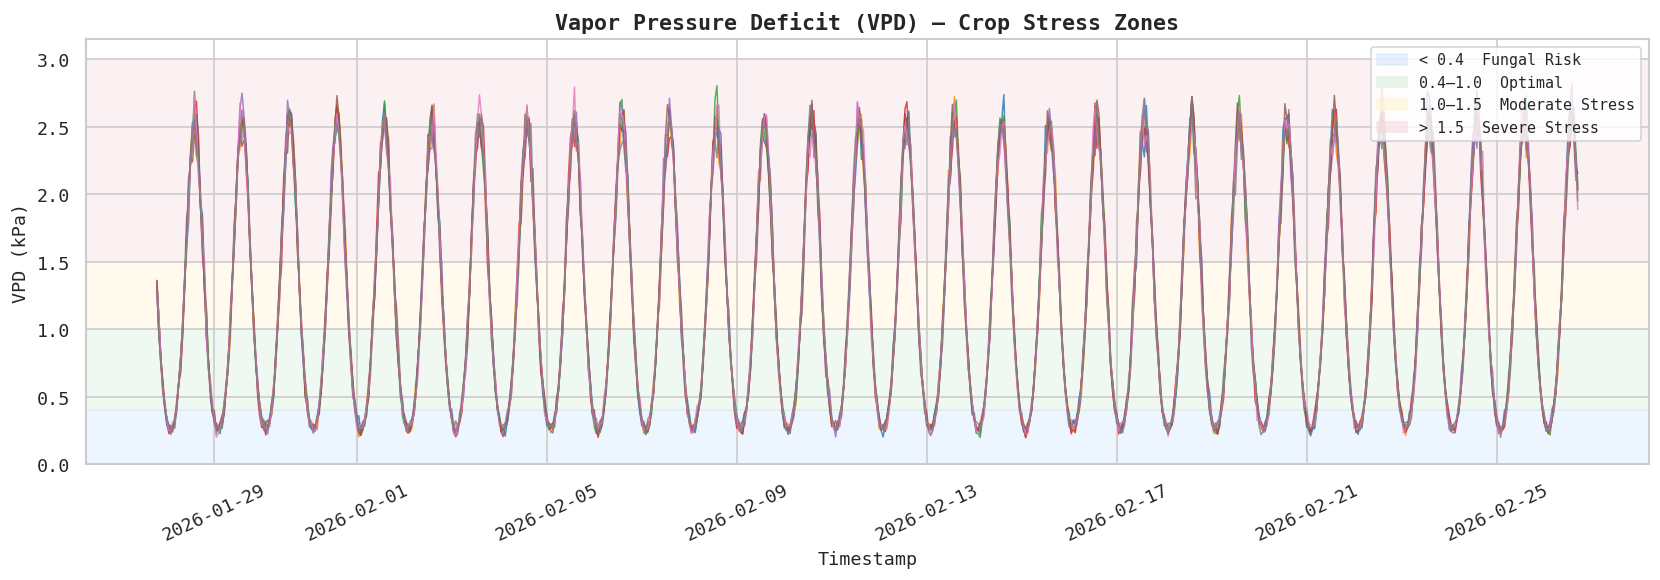

In [7]:
# Celda 6: VPD con zonas de estres hidrico
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
import matplotlib.pyplot as plt
from demeter_sdk import viz

fig = viz.plot_vpd(df)
plt.show()

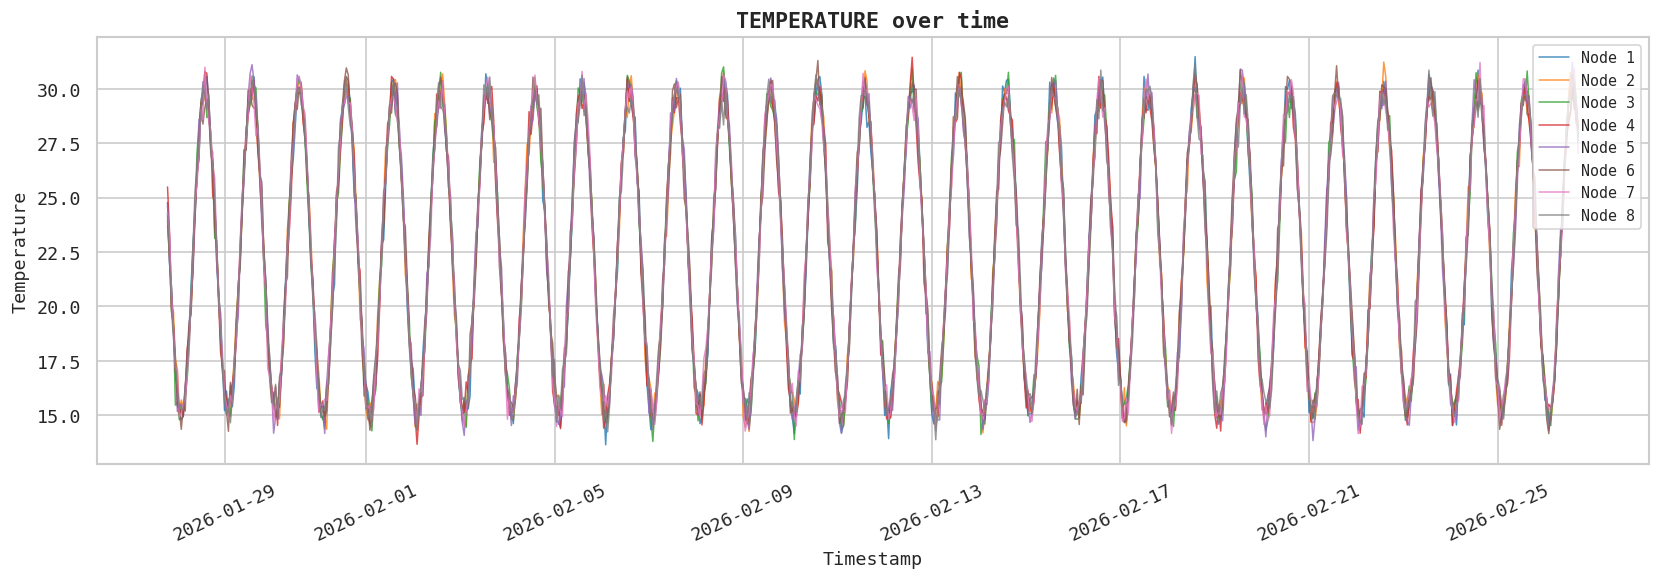

In [8]:
# Celda 7: Timeseries de temperatura
fig = viz.plot_timeseries(df, sensor='temperature', moving_avg=True)
plt.show()

/home/danielmf31/Documentos/PlatformIO/Projects/Proyecto_Demeter/SDK/demeter_sdk/viz.py:191: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=x_col, y=metric, palette=_PALETTE, ax=ax)


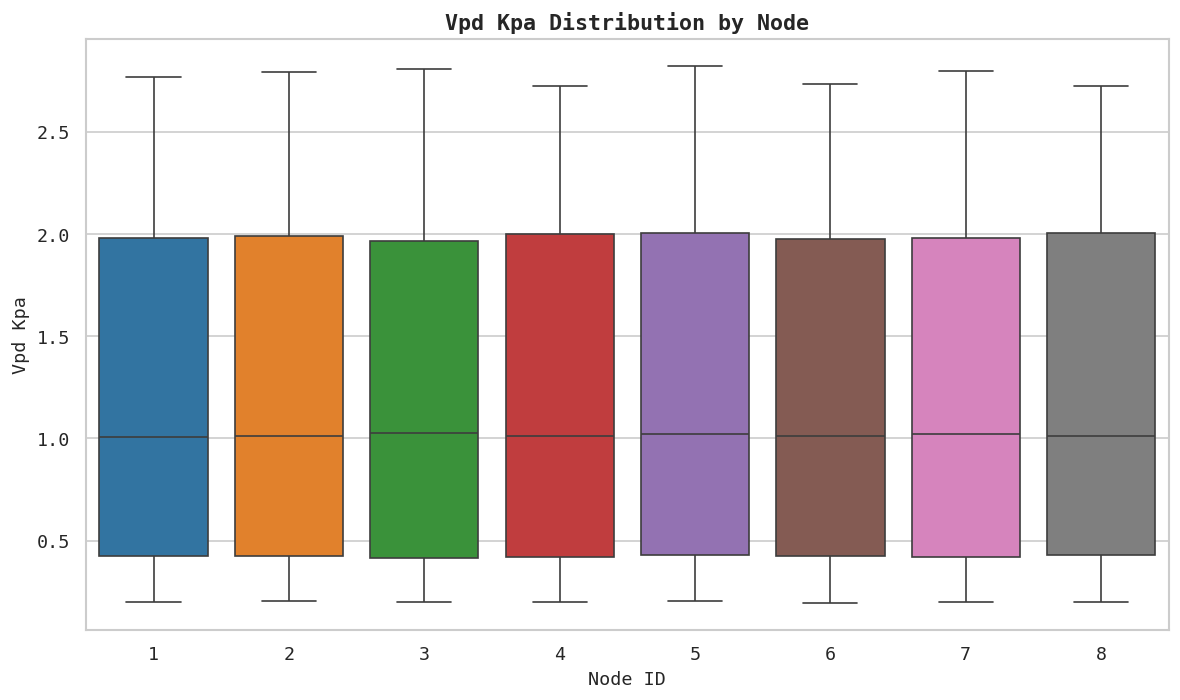

In [9]:
# Celda 8: Boxplot por nodo
fig = viz.plot_boxplot(df, metric='vpd_kpa')
plt.show()

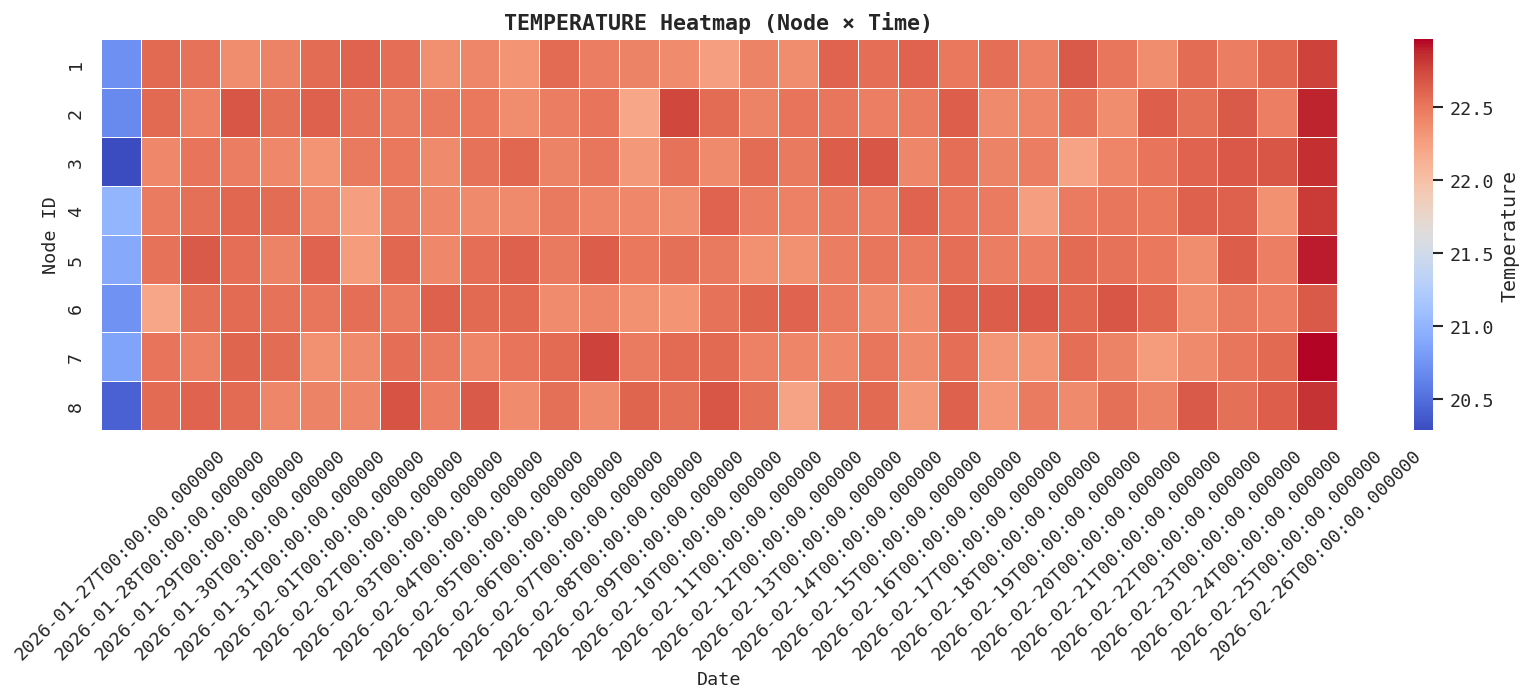

In [10]:
# Celda 9: Heatmap temperatura x nodo
fig = viz.plot_heatmap(df, metric='temperature', resample_rule='1D')
plt.show()

In [11]:
# Celda 10: Exportar Excel y descargar
from demeter_sdk import export

path = export.to_excel(
    df_enriched=df,
    path='/tmp/demeter_patata_report.xlsx',
    experiment_name=f'Experimento {EXP_ID} - patata.monters.org',
)
print(f'Excel generado: {path} ({path.stat().st_size // 1024} KB)')

try:
    from google.colab import files
    files.download(str(path))
except ImportError:
    print(f'Archivo disponible en: {path}')

2026-02-26 19:28:04,363 [demeter_sdk.export] INFO — Excel saved → /tmp/demeter_patata_report.xlsx  (905.8 KB, 5752 enriched rows)


Excel generado: /tmp/demeter_patata_report.xlsx (905 KB)
Archivo disponible en: /tmp/demeter_patata_report.xlsx


In [12]:
# Celda 11: Exportar CSV
csv_path = export.to_csv(df, '/tmp/telemetria_patata.csv')
print(f'CSV: {csv_path} ({csv_path.stat().st_size // 1024} KB)')

try:
    from google.colab import files
    files.download(str(csv_path))
except ImportError:
    pass

2026-02-26 19:28:04,443 [demeter_sdk.export] INFO — CSV saved → /tmp/telemetria_patata.csv  (5752 rows × 17 cols)


CSV: /tmp/telemetria_patata.csv (1336 KB)
